# 04 · Model Training

## 1. Objective
Train the three required classical models, tune them with cross-validation **on the training set only**, and pick the final model *before* the test set is looked at.

> ⚠️ *Educational demonstration - not for medical diagnosis or clinical decisions.*

## Concepts in plain language
**Logistic Regression** - despite the name, a classifier. It computes a weighted sum of the features, then squashes it through the *sigmoid* function into a probability between 0 and 1. If probability ≥ threshold (default 0.5) → predict CKD. Weights (*coefficients*) are learned so predicted probabilities match the labels. It is the interpretable baseline: each coefficient says how a feature moves the *log-odds* of CKD. **Scaling matters** because regularisation penalises large coefficients - a feature measured in thousands (WBC count) would otherwise be treated differently from one measured in single digits. `C` is the inverse regularisation strength (small C = stronger penalty).

**Decision Tree** - a flowchart of yes/no questions. Each *node* asks e.g. "hemoglobin ≤ 12.9?" and splits patients into two groups. The tree picks the split that makes the groups *purest*. **Gini impurity** = 1 − Σ pᵢ² (0 = pure group, 0.5 = 50/50 mix for 2 classes); **entropy / information gain** is an alternative purity measure (information gain = drop in entropy after the split). A deep tree can memorise the training data (**overfitting**), so we limit `max_depth` and `min_samples_leaf`.

**Random Forest** - many trees voting. *Ensemble learning* combines several models. Each tree trains on a **bootstrap sample** (random draw with replacement) and, at each split, considers only a **random subset of features**. Trees therefore differ; averaging their votes **reduces variance** (less overfitting than one tree). Feature importance = how much each feature reduces impurity across the forest.

**Cross-validation (CV)** - split the training data into 5 folds; train on 4, validate on 1, rotate. Gives a mean and std of the score. **Stratified** keeps class ratios in every fold.

**Hyperparameter tuning** - hyperparameters (depth, C, ...) are settings we choose *before* training. `GridSearchCV` tries every combination in a small grid using CV. The test set is never used for this.

## 2. Imports

In [1]:
import sys, warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # make `src` importable from notebooks/
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
FIG = Path.cwd().parent / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
def savefig(name): plt.savefig(FIG / name, bbox_inches="tight", dpi=150)

In [2]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import validation_curve
from src.data_preprocessing import load_and_clean, split_data, build_preprocessor
from src.feature_engineering import get_feature_names
from src.train import make_pipeline, get_cv, get_model_specs, run_training, SCORING
df, _ = load_and_clean(save=False)
X_train, X_test, y_train, y_test = split_data(df)      # X_test is NOT used in this notebook
print("Training rows:", len(X_train))

Training rows: 320


## 3-4. Understanding overfitting: Decision-Tree depth
We plot training accuracy vs cross-validated accuracy as trees get deeper. A widening gap = overfitting.

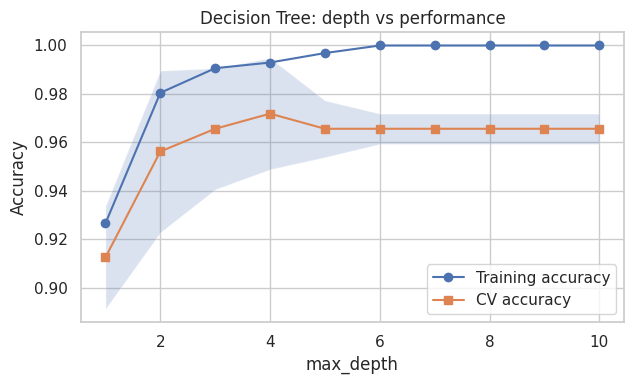

In [3]:
depths = list(range(1, 11))
tr, va = validation_curve(make_pipeline(DecisionTreeClassifier(random_state=42)), X_train, y_train,
                          param_name="model__max_depth", param_range=depths, cv=get_cv(), scoring="accuracy")
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(depths, tr.mean(1), "o-", label="Training accuracy"); ax.plot(depths, va.mean(1), "s-", label="CV accuracy")
ax.fill_between(depths, va.mean(1)-va.std(1), va.mean(1)+va.std(1), alpha=.2)
ax.set(xlabel="max_depth", ylabel="Accuracy", title="Decision Tree: depth vs performance"); ax.legend()
plt.tight_layout(); savefig("decision_tree_depth_curve.png"); plt.show()

Training accuracy climbs towards 100% with depth, while CV accuracy plateaus (and its spread shows the model is sensitive to which patients are in the fold). Depth beyond the plateau adds complexity without benefit.

### A shallow tree you can read (depth 3, training data only)

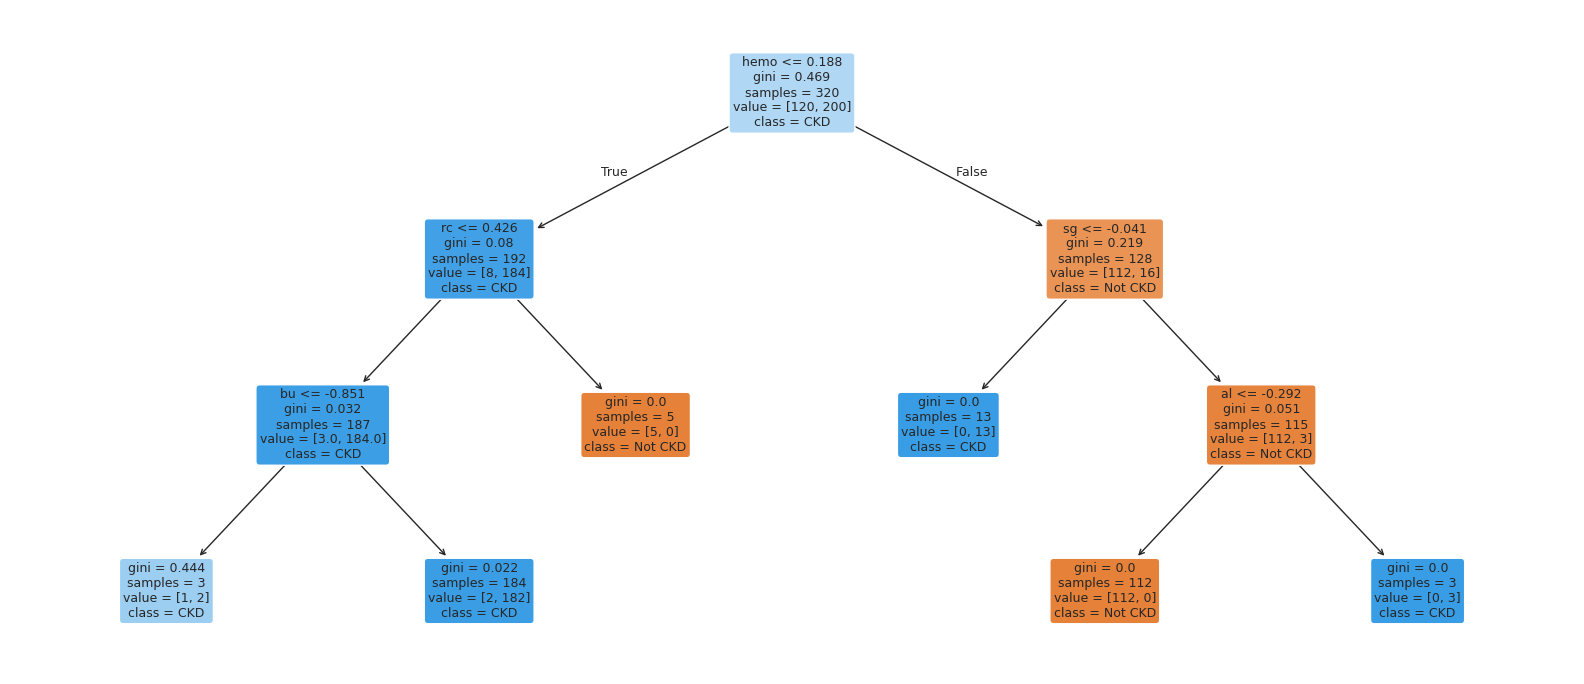

In [4]:
pre = build_preprocessor().fit(X_train)
names = get_feature_names(pre)
small = DecisionTreeClassifier(max_depth=3, random_state=42).fit(pre.transform(X_train), y_train)
fig, ax = plt.subplots(figsize=(16, 7))
plot_tree(small, feature_names=names, class_names=["Not CKD", "CKD"], filled=True, rounded=True, fontsize=9, ax=ax)
plt.tight_layout(); savefig("decision_tree_depth3.png"); plt.show()

Each box shows the split rule, the Gini impurity, sample count, class counts and the majority class. *Note the numeric thresholds are in **scaled** units (standard deviations from the training mean) because the tree was trained on preprocessed data.*

## 5-8. Baseline CV, hyper-parameter tuning, selection
`run_training()` (in `src/train.py`) does, for each model: (1) untuned 5-fold stratified CV, (2) `GridSearchCV` (refit on F1) inside the training set, (3) saves the fitted pipeline, and finally (4) applies a **written selection rule** using CV results only.

Search grids are deliberately small because the dataset is small.

In [5]:
for name, (est, grid) in get_model_specs().items():
    print(f"{name}: grid = { {k.replace('model__',''): v for k, v in grid.items()} }")

Logistic Regression: grid = {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs', 'liblinear'], 'class_weight': [None, 'balanced']}
Decision Tree: grid = {'max_depth': [2, 3, 4, 5, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'criterion': ['gini', 'entropy'], 'class_weight': [None, 'balanced']}
Random Forest: grid = {'n_estimators': [100, 300], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2], 'max_features': ['sqrt', 'log2'], 'class_weight': [None, 'balanced']}


In [6]:
res = run_training(verbose=True)
cv = res["cv_results"]

Logistic Regression: best params {'C': 10, 'class_weight': 'balanced', 'solver': 'liblinear'}  (CV F1=0.9975)


Decision Tree: best params {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}  (CV F1=0.9851)


Random Forest: best params {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}  (CV F1=0.9951)

Selected (CV-based, before test evaluation): Logistic Regression
Ranked by CV recall, then CV F1, then CV ROC-AUC (3 d.p.), then interpretability. Logistic Regression: recall=1.000, F1=0.998, ROC-AUC=1.000.


### Cross-validation results (training set only - NOT test results)

In [7]:
fmt = cv.copy()
for m in SCORING: fmt[m] = fmt[f"{m}_mean"].map("{:.3f}".format) + " ± " + fmt[f"{m}_std"].map("{:.3f}".format)
display(fmt[["model", "stage"] + SCORING].style.hide(axis="index"))

model,stage,accuracy,precision,recall,f1,roc_auc
Logistic Regression,Baseline,0.991 ± 0.012,0.990 ± 0.019,0.995 ± 0.010,0.993 ± 0.010,1.000 ± 0.000
Logistic Regression,Tuned,0.997 ± 0.006,0.995 ± 0.010,1.000 ± 0.000,0.998 ± 0.005,1.000 ± 0.000
Decision Tree,Baseline,0.966 ± 0.006,0.976 ± 0.025,0.970 ± 0.019,0.973 ± 0.004,0.964 ± 0.014
Decision Tree,Tuned,0.981 ± 0.018,0.980 ± 0.018,0.990 ± 0.012,0.985 ± 0.014,0.978 ± 0.021
Random Forest,Baseline,0.991 ± 0.012,0.986 ± 0.019,1.000 ± 0.000,0.993 ± 0.010,0.999 ± 0.001
Random Forest,Tuned,0.994 ± 0.008,0.990 ± 0.012,1.000 ± 0.000,0.995 ± 0.006,1.000 ± 0.001


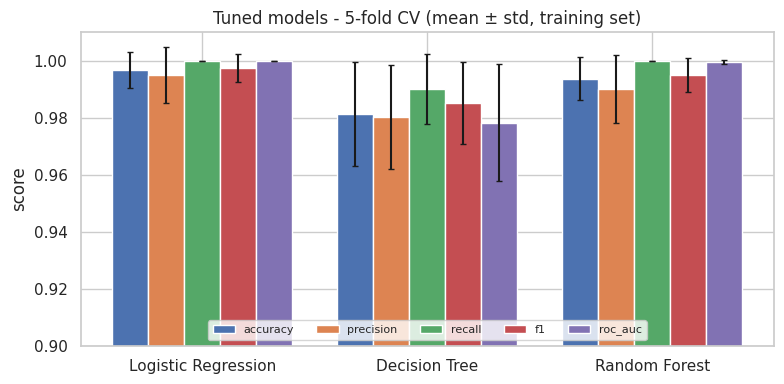

Best hyper-parameters:
Logistic Regression    {'C': 10, 'class_weight': 'balanced', 'solver'...
Decision Tree          {'class_weight': 'balanced', 'criterion': 'ent...
Random Forest          {'class_weight': 'balanced', 'max_depth': None...


In [8]:
tuned = cv[cv.stage == "Tuned"].set_index("model")
fig, ax = plt.subplots(figsize=(8, 4)); w = 0.16
for i, m in enumerate(SCORING):
    ax.bar(np.arange(3) + (i-2)*w, tuned[f"{m}_mean"], w, yerr=tuned[f"{m}_std"], label=m, capsize=2)
ax.set_xticks(range(3)); ax.set_xticklabels(tuned.index); ax.set_ylim(0.9, 1.01)
ax.set(title="Tuned models - 5-fold CV (mean ± std, training set)", ylabel="score"); ax.legend(ncol=5, fontsize=8, loc="lower center")
plt.tight_layout(); savefig("cv_comparison.png"); plt.show()
print("Best hyper-parameters:"); print(pd.Series(res["best_params"]).to_string())

### Reading these numbers honestly
- All three models score very high in CV. Differences between Logistic Regression and Random Forest are **smaller than the fold-to-fold standard deviations**, so they are not clearly distinguishable.
- The *tuned* CV scores are slightly **optimistic**: the same folds were used to choose the hyper-parameters and to report the score. (Nested CV would remove this bias; the test set gives an independent check.)
- The Decision Tree is the weakest and least stable (largest std), consistent with a single tree's high variance.

### Model selection
The rule (in `select_final_model`): rank by CV **recall** (missing a CKD case is the costly error in a screening-style setting) → CV F1 → CV ROC-AUC (rounded to 3 dp) → interpretability. Recall-first is a *stated priority of this project*, not a universal clinical truth: raising recall usually lowers precision (more false alarms and follow-up tests).

In [9]:
print("FINAL MODEL (chosen from CV, before the test set is scored):", res["final_model"])
print(res["rationale"])

FINAL MODEL (chosen from CV, before the test set is scored): Logistic Regression
Ranked by CV recall, then CV F1, then CV ROC-AUC (3 d.p.), then interpretability. Logistic Regression: recall=1.000, F1=0.998, ROC-AUC=1.000.


## 10. Conclusions
- Three pipelines (preprocessing + model) trained and tuned with stratified 5-fold CV; the test set was never touched.
- The selection decision is saved to `reports/selection.json` **before** evaluation - so we can't be tempted to cherry-pick on test results.
- Near-ties are resolved by the documented rule (with interpretability as a final tie-break).